### JURNAL SEMENTARA 
Mustafida (F1D02410126)

In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

(720, 720, 3)


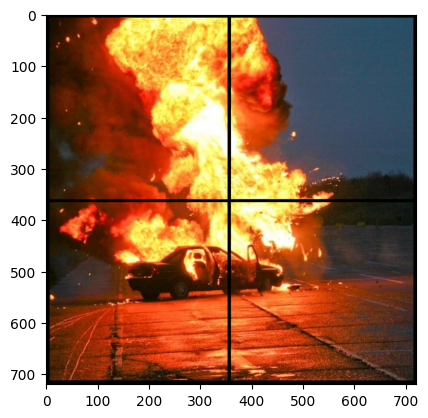

In [20]:
Meledak = plt.imread('Assets/Meledak.png')

plt.imshow(Meledak)
print(Meledak.shape)
plt.show()

### Pemisahan

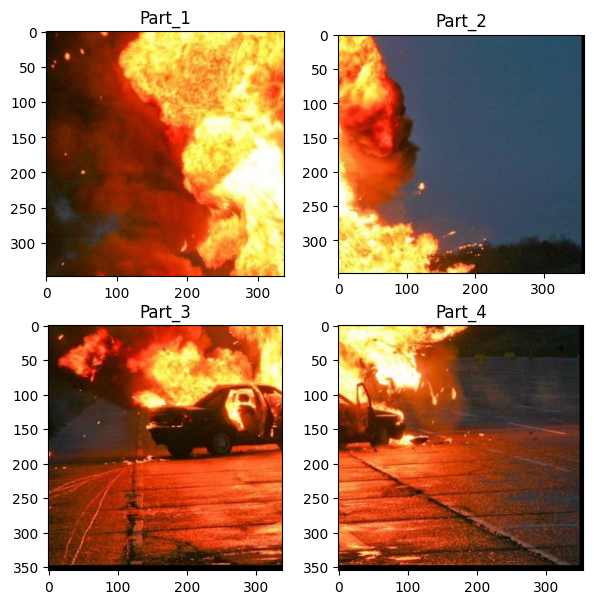

In [21]:
def slicing (gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar [:, a:b]

cut1 = slicing (Meledak, 12, 360)
gambar_1 = slicing(cut1, 12, 350, 'V')
gambar_2 = slicing(cut1, 360, 720, 'V')

cut2 = slicing (Meledak, 365, 720)
gambar_3 = slicing(cut2, 12, 350, 'V')
gambar_4 = slicing(cut2, 365, 720, 'V')

plt.figure(figsize=(7,7))

plt.subplot(2, 2, 1)
plt.imshow (gambar_1)
plt.title("Part_1")

plt.subplot(2, 2, 2)
plt.imshow (gambar_2)
plt.title("Part_2")

plt.subplot(2, 2, 3)
plt.imshow (gambar_3)
plt.title("Part_3")

plt.subplot(2, 2, 4)
plt.imshow (gambar_4)
plt.title("Part_4")
plt.show()

### Penggabungan

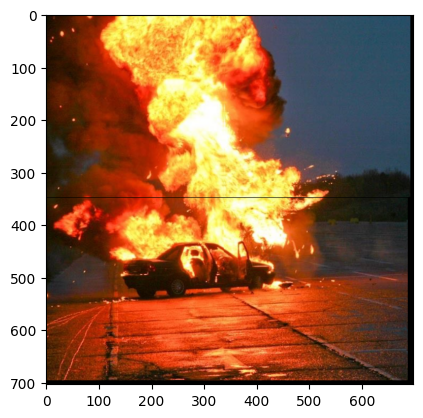

In [22]:
def merge_image(citra1, citra2, orientation='H'):
    if orientation == 'H':
        tinggi = max(citra1.shape[0], citra2.shape[0])
        lebar_total = citra1.shape[1] + citra2.shape[1]
        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype)
                
            gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
            gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2
    else:
            tinggi_total = citra1.shape[0] + citra2.shape[0]
            lebar = max(citra1.shape[1], citra2.shape[1])
            if len(citra1.shape) == 2:
                gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype)
            else:
                gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype)
                gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
                gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2
    return gabungan
gabungan1 = merge_image(gambar_1, gambar_2, 'H')
gabungan2 = merge_image(gambar_3, gambar_4, 'H')
gabungan3 = merge_image(gabungan1, gabungan2, 'W')
plt.imshow(gabungan3)
plt.show()

### Grayscale

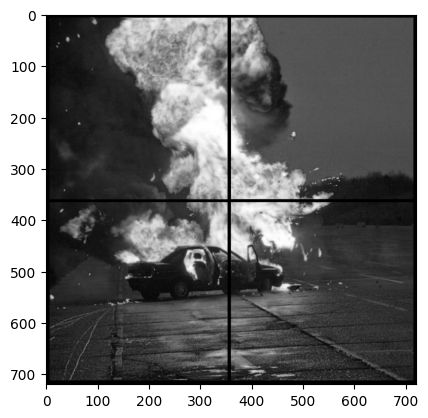

In [23]:
img = plt.imread('Assets/Meledak.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')


##### Code ikutin yang di Panduan
(maaf bang ada yang error sy ikutin yg panduan hm..)

In [24]:
def ekualisasi(citra):
    height, width = citra.shape

    # Histogram
    hist = np.zeros(256, dtype=int)
    for y in range(height):
        for x in range(width):
            pixel = citra[y, x]
            hist[pixel] += 1

    # CDF
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    # Cari CDF minimum selain nol
    cdf_min = 0
    for i in range(256):
        if cdf[i] != 0:
            cdf_min = cdf[i]
            break

    # Normalisasi CDF yang benar
    cdf_normal = np.round(
        (cdf - cdf_min) /
        ((height * width) - cdf_min)
        * 255
    )

    cdf_normal = np.clip(
        cdf_normal,
        0,
        255
    ).astype(np.uint8)

    # Hasil ekualisasi
    hasil = np.zeros_like(citra)

    for y in range(height):
        for x in range(width):
            pixel = citra[y, x]
            hasil[y, x] = cdf_normal[pixel]
    return hasil

# Menampilkan hasil
plt.figure(figsize=(12,5))
ekual = ekualisasi(gabungan1, gabungan2, gabungan3)
plt.imshow(ekual, cmap='gray')
plt.axis('off')
plt.title('Hasil Ekualisasi')

TypeError: ekualisasi() takes 1 positional argument but 3 were given

<Figure size 1200x500 with 0 Axes>

In [ ]:
def buat_hist(citra):
    histogram = [0] * 256
    height = len(citra)
    width = len(citra[0]) if height > 0 else 0
    for i in range(height):
        for j in range(width):
            val = int(citra[i][j])
            histogram[val] += 1
    return histogram
def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)

    plt.imshow(gray)
    plt.show()

### Tampilan Grayscale

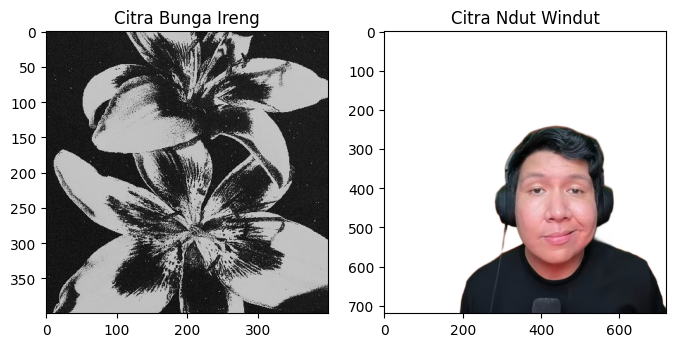

In [37]:
citra_Windut = plt.imread('Assets/Windut.png', cv2.IMREAD_GRAYSCALE)
citra_Bunga = plt.imread('Assets/Bunga.png', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8, 12))

plt.subplot(2,2,2)
plt.imshow(citra_Windut, cmap='gray')
plt.title("Citra Ndut Windut")

plt.subplot(2,2,1)
plt.imshow(citra_Bunga, cmap='gray')
plt.title("Citra Bunga Ireng")

plt.show()